In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import matplotlib.dates as mdates

In [2]:
sys.path.append("../src")
from anomalies import TemporalAnomalyDetector
from utils import ForensicVisualizer

In [3]:
# Configuración de Rutas
BASE_DIR = Path.cwd().parent
CSV_CHATS = BASE_DIR / "data" / "processed" / "chats_completos.csv"

# Cargamos el Golden Dataset de la Fase 1
df_chats = pd.read_csv(CSV_CHATS)

In [4]:
# Fijamos un 3% de anomalías esperadas
detector = TemporalAnomalyDetector(contamination=0.03) 
df_prepared = detector.prepare_features(df_chats)

# USAMOS LAS VARIABLES LOGARÍTMICAS PARA EVITAR EL SESGO DE LOS SALTOS TEMPORALES
features_to_model = ['Hour', 'Length_Log', 'Time_Delta_Log']

# Ejecución del Modelo Predictivo
df_anomalies = detector.fit_predict(df_prepared, features_to_model)

Realizando Feature Engineering temporal avanzado...
Entrenando Isolation Forest sobre 797 eventos...


In [5]:
# 3. Métricas Básicas
anomalos = df_anomalies[df_anomalies['Is_Anomaly'] == -1]
normales = df_anomalies[df_anomalies['Is_Anomaly'] == 1]

print(f"\n--- Resumen del Isolation Forest ---")
print(f"Total de eventos evaluados: {len(df_anomalies)}")
print(f"Comportamientos Normales: {len(normales)}")
print(f"Anomalías Detectadas (Crisis/Atípicos): {len(anomalos)}")


--- Resumen del Isolation Forest ---
Total de eventos evaluados: 797
Comportamientos Normales: 773
Anomalías Detectadas (Crisis/Atípicos): 24


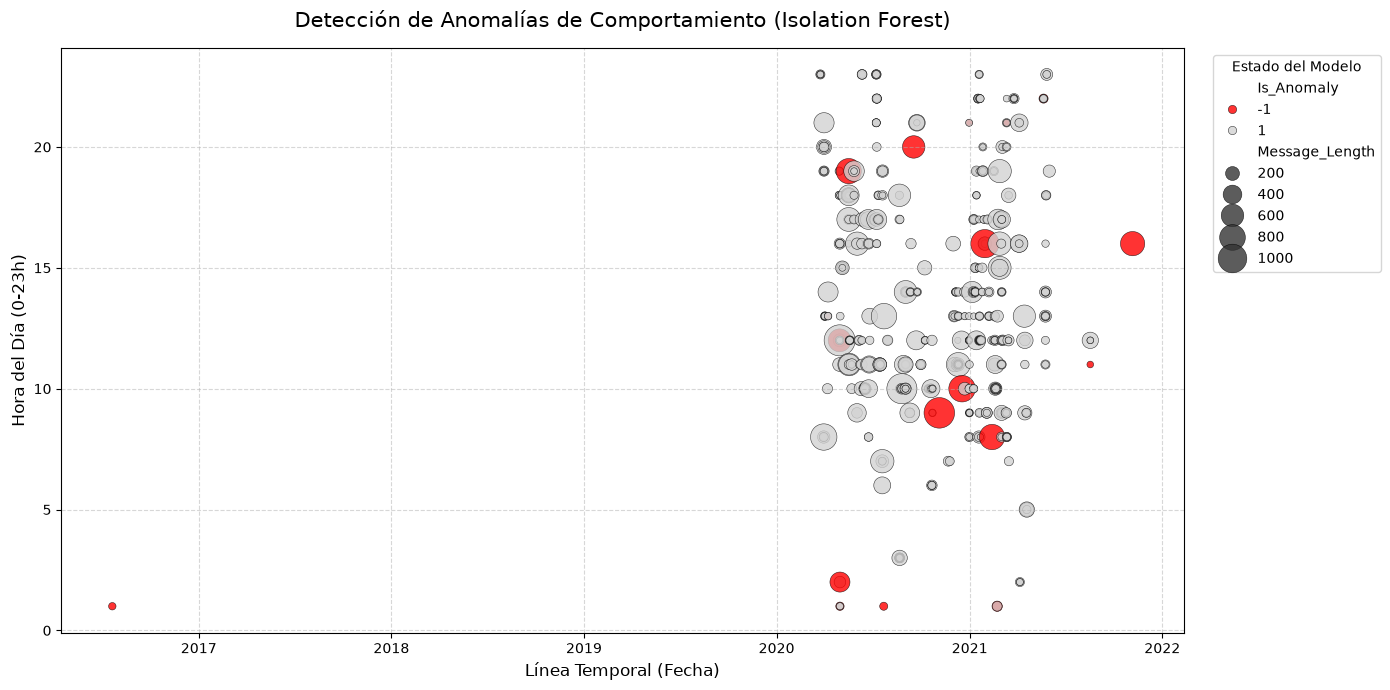

In [6]:
# 4. Visualización
# Gráfico de Dispersión Temporal
ForensicVisualizer.plot_anomaly_scatter(df_anomalies)

In [7]:
# 5. Volcado Analítico del Top 10 Anomalías
columnas_mostrar = ['Datetime', 'Emisor', 'Hour', 'Message_Length', 'Time_Delta_Sec', 'Anomaly_Score', 'Mensaje']
top_anomalias = anomalos.sort_values(by='Anomaly_Score').head(10)

print("\n--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---")
display(top_anomalias[columnas_mostrar])


--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---


,Datetime,Emisor,Hour,Message_Length,Time_Delta_Sec,Anomaly_Score,Mensaje
408,2020-11-04 09:15:19,ROBERTO ROSELLI,9,1149,1119296.0,-0.055674,“Acabo de hablar con el tipo de la SEPI. Estáb...
600,2021-01-29 16:35:15,JULIO MARTINEZ SOLA,16,971,0.0,-0.048667,Parece que bien en el sentido de que se le dev...
1,2020-03-23 23:06:48,Miguel Palomero,23,36,115938777.0,-0.047275,Que vais a hacer con la línea aérea?
653,2021-02-22 01:03:59,RODOLFO REYES,1,34,225691.0,-0.035146,Alguna noticia de Antonio Caldeiro
0,2016-07-21 01:53:51,Ramón GORDILS,1,23,0.0,-0.034051,Moncho Gordils por aqui
796,2021-11-05 16:04:54,JULIO MARTÍNEZ SOLA,16,705,6923797.0,-0.032574,Me acaba de llamar a José Ángel Partearroyo de...
101,2020-04-30 02:03:41,RAMÓN GORDILS,2,466,72.0,-0.032241,Tranquilo... Ya nos enteraremos *** En el inte...
284,2020-07-22 01:07:16,DESCONOCIDO,1,36,193788.0,-0.031850,Si bro. Nuestro pana zapatero detrás
291,2020-08-21 03:07:09,ROBERTO ROSELLI,3,5,31341.0,-0.031404,Mamao
656,2021-02-22 01:04:25,RODOLFO REYES,1,8,6.0,-0.030489,Si porfa


In [8]:
CSV_TOP_CHATS = BASE_DIR / "data" / "processed" / "chats_top.csv"
top_anomalias[columnas_mostrar].to_csv(CSV_TOP_CHATS)

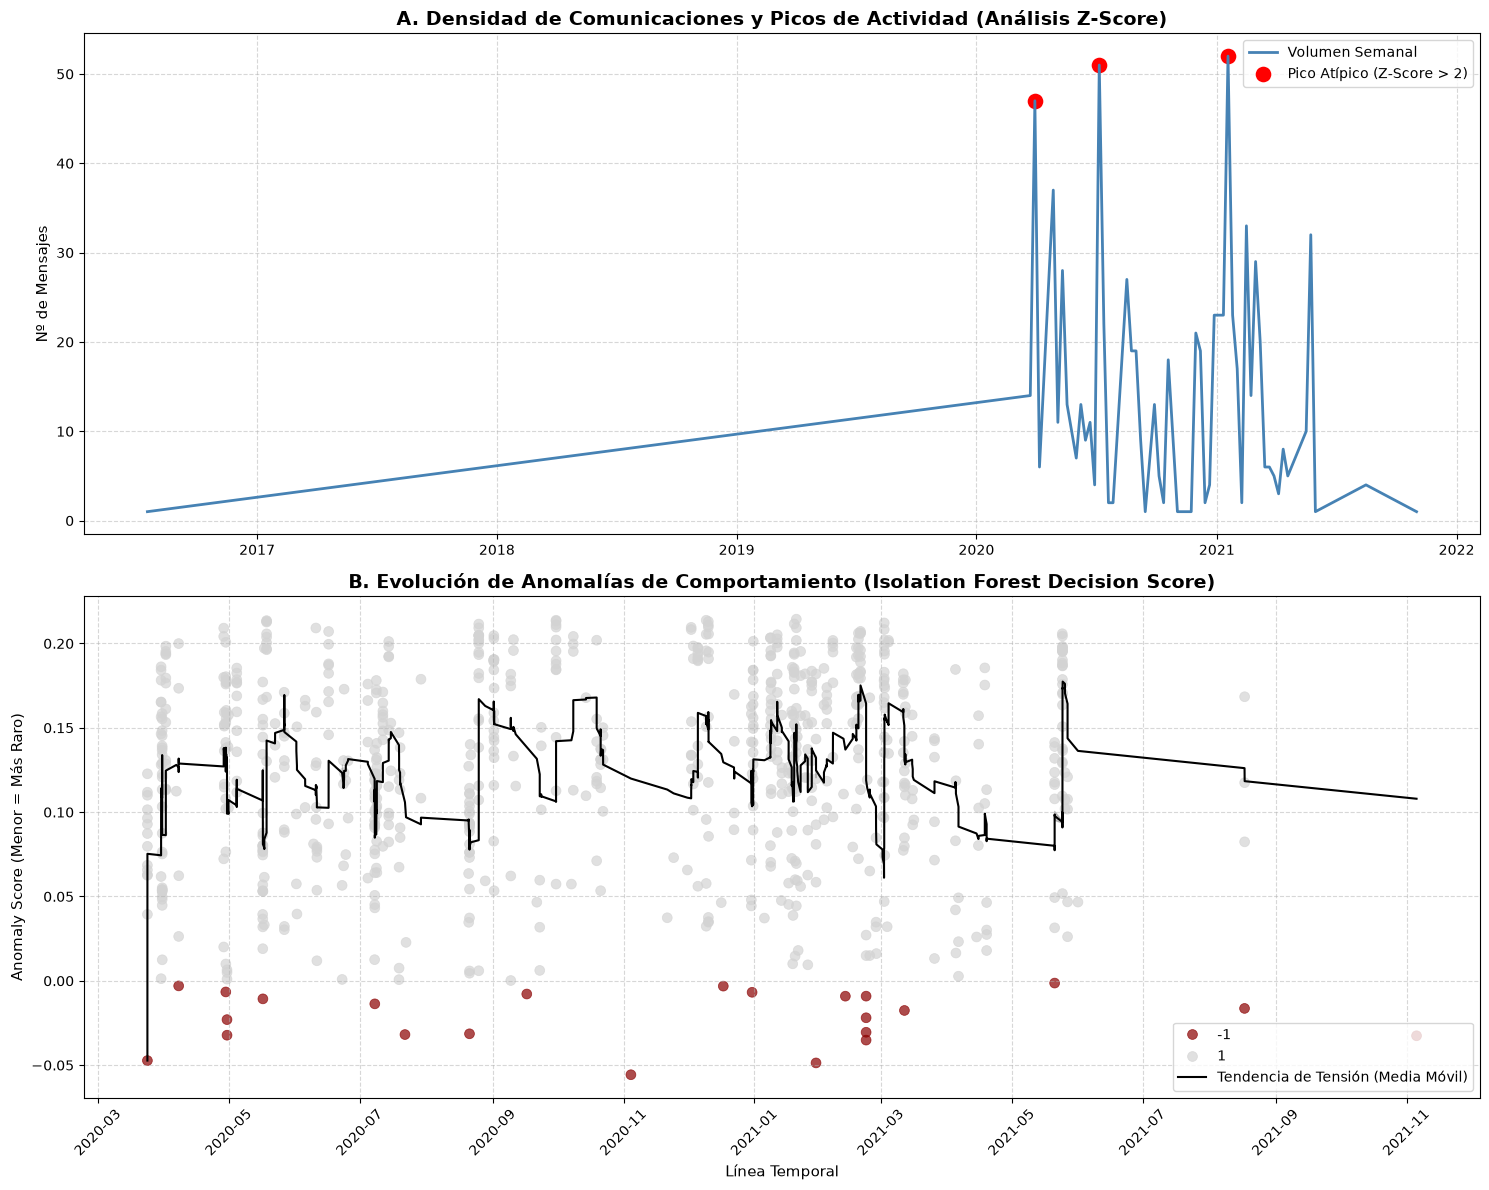

In [9]:
# Panel Dual de Densidad y Anomalías
ForensicVisualizer.plot_temporal_density_and_scores(df_anomalies)